In [3]:
library(slendr)
init_env()

## _slendr_ models and "direction of time"

#### Exercise: Creating a population assuming a forward direction of time

Let's start with the simplest possible _slendr_ simulation possible—a simulation of the demographic history of a single population.

First, **create an R variable `pop` containing a _slendr_ population (using the `population()` function) with the `name` "pop", at `time` 1 and a size `N` of 5000**.

**Note:** At this moment, the `time` value has a completely arbitrary unit to be determined later. Additionally, unless otherwise specified, the size `N` will always indicate the "effective population size" $N_e$.

**Execute your code which stores the population in the `pop` variable, then type out `pop` in your R console. What does the summary report back to you?**

In [29]:
pop <- population("pop", time = 1, N = 5000)

In [30]:
print(pop)

slendr 'population' object 
-------------------------- 
name: pop 
non-spatial population
stays until the end of the simulation

population history overview:
  - time 1: created as an ancestral population (N = 5000)


#### Exercise: Compiling the model

In [31]:
model <- compile_model(
  populations = pop,
  generation_time = 1,
  direction = "forward",
  simulation_length = 3000
)

In [32]:
print(model)

slendr 'model' object 
--------------------- 
populations: pop 
geneflow events: [no geneflow]
generation time: 1 
time direction: forward 
time units: generations 
total running length: 3000 time units
model type: non-spatial

configuration files in: /private/var/folders/7f/n68ck8q969z_d628zqqnl4ch0000gn/T/RtmpZ1SfSL/file1bf6a5d7cb_slendr_model 


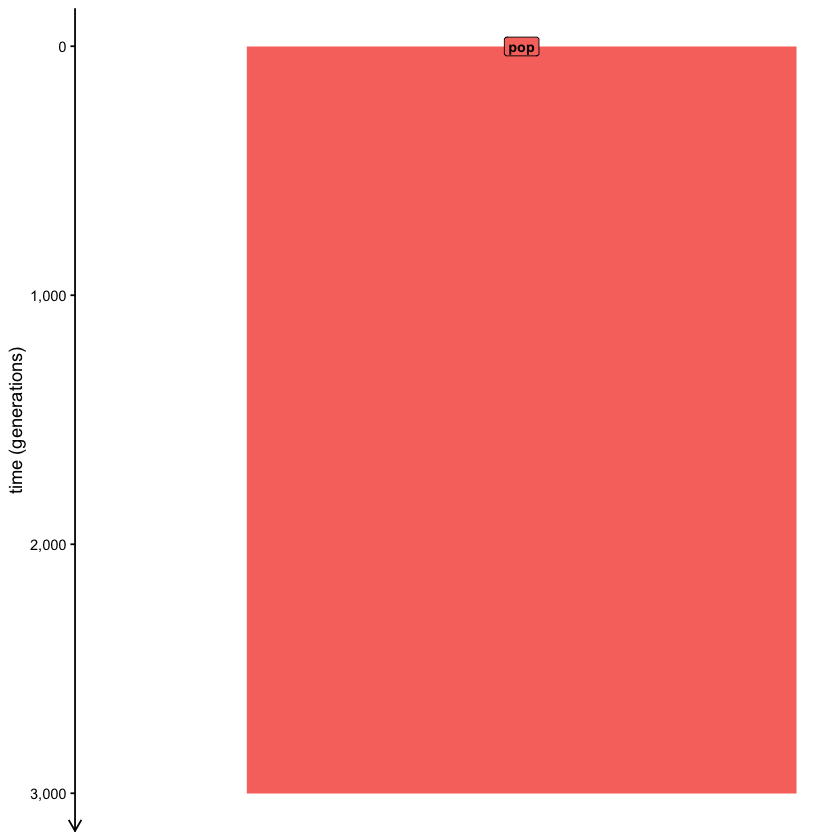

In [33]:
plot_model(model)

#### Exercise: Specifying generation time and time units

In [34]:
model <- compile_model(
  populations = pop,
  generation_time = 30,
  direction = "forward",
  simulation_length = 1000
)

In [36]:
print(model)

slendr 'model' object 
--------------------- 
populations: pop 
geneflow events: [no geneflow]
generation time: 30 
time direction: forward 
time units:  
total running length: 1000 time units
model type: non-spatial

configuration files in: /private/var/folders/7f/n68ck8q969z_d628zqqnl4ch0000gn/T/RtmpZ1SfSL/file1bf627ace5ff_slendr_model 


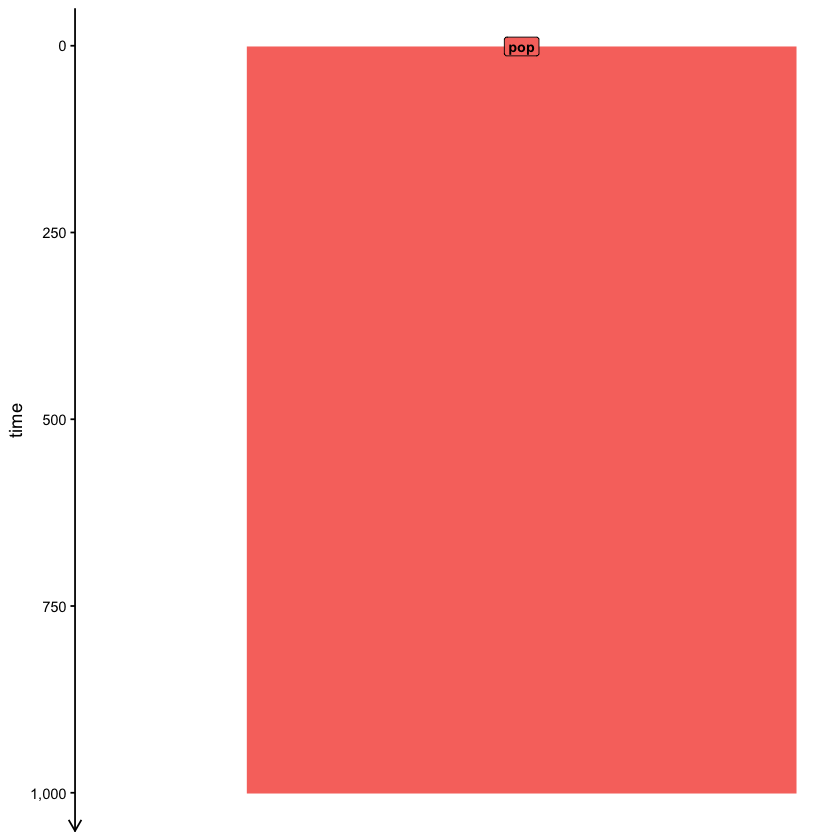

In [37]:
plot_model(model)

#### Exercise: Backward direction of time

It's very easy to undestand models specified in time units going forward. However, in many practical situation in population genomics (and especially whenever we deal with ancient DNA samples), times of events specified in units such as "years before the present" are much easier to program, read, and interpret.

For instance, if we want to simulate a split of a lineage of anatomically modern humans from their chimpanzee relatives, it's much easier to say that it probably happened around six million years ago looking "backwards in time" and assuming that "present day" is counted at time 0, rather than having to recalculate all of these times now only into generations but also into generations going "forward" starting from a hypothetical time of 1 sometime in the past (like we did in the very first simulation above).

In [16]:
pop <- population("pop", time = 1000, N = 5000)

In [17]:
print(pop)

slendr 'population' object 
-------------------------- 
name: pop 
non-spatial population
stays until the end of the simulation

population history overview:
  - time 1000: created as an ancestral population (N = 5000)


In [32]:
model <- compile_model(
  populations = pop,
  generation_time = 1,
  direction = "backward"
)

In [33]:
print(model)

slendr 'model' object 
--------------------- 
populations: pop 
geneflow events: [no geneflow]
generation time: 1 
time direction: backward 
time units: generations 
total running length: 1000 time units
model type: non-spatial

configuration files in: /private/var/folders/7f/n68ck8q969z_d628zqqnl4ch0000gn/T/RtmpARrgsq/file3bbc11c54758_slendr_model 


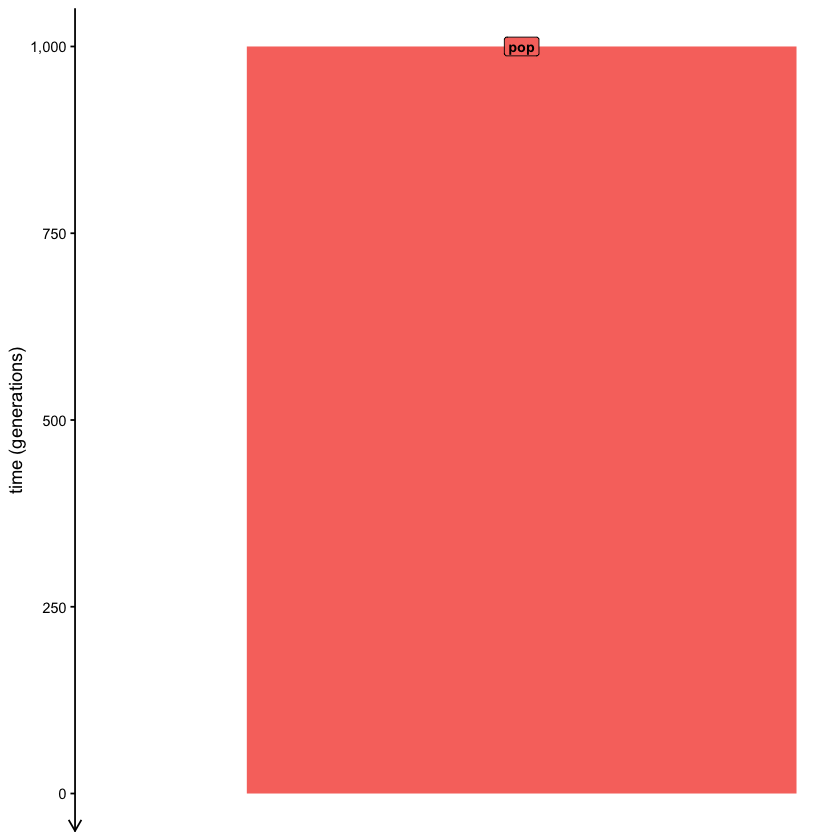

In [34]:
plot_model(model)

### Exercise: Resize events

#### Immediate resizes

In [45]:
pop <- population("pop", time = 1, N = 5000) %>% resize(N = 2000, time = 500, how = "step")

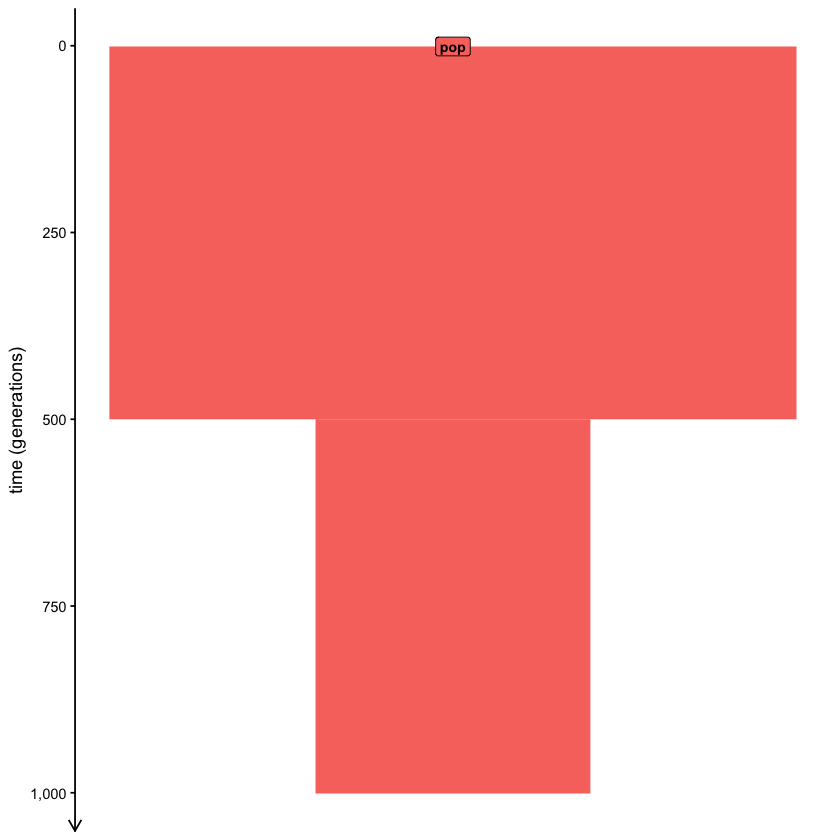

In [46]:
model <- compile_model(populations = pop, generation_time = 1, direction = "forward", simulation_length = 1000)
plot_model(model)

#### Exponential resizes

In [62]:
pop <- population("pop", time = 1, N = 5000) %>% resize(N = 15000, time = 400, end = 600, how = "exponential")

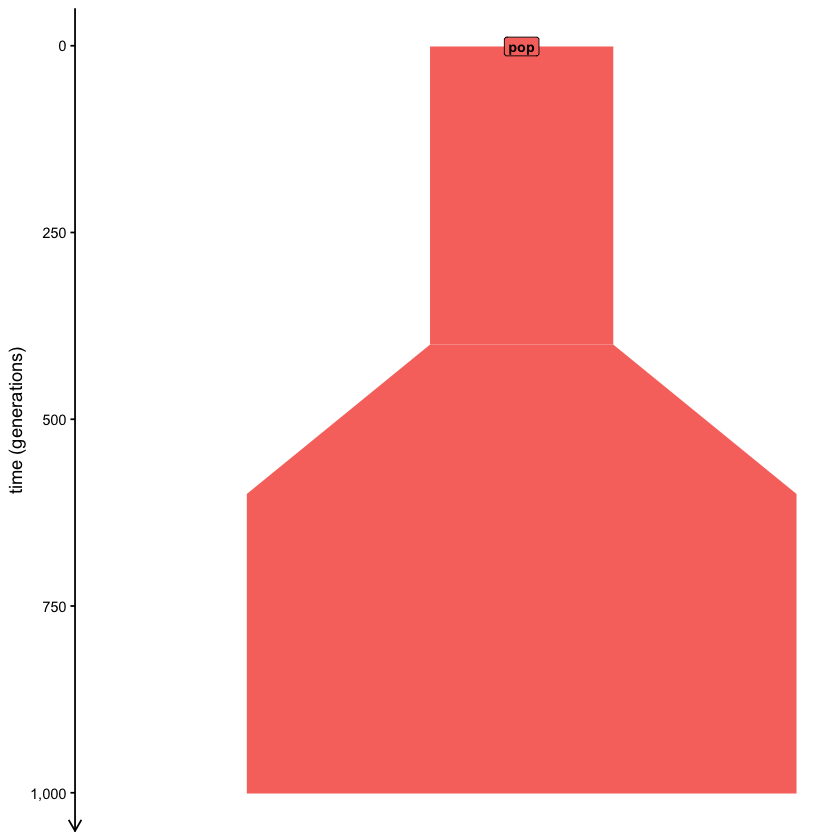

In [63]:
model <- compile_model(populations = pop, generation_time = 1, direction = "forward", simulation_length = 1000)
plot_model(model)

### Exercise: Encoding gene flow (admixture, introgression)

Of course, real-world populations don't just split from one another or change their size. A very common demographic process is gene flow (also called admixture or introgression in various context and different species).

**Use the function `gene_flow()` to program admixture from population "p1" into population "p2" at starting at `time` 100, with an `end` at time `200`. Set the total `proportion` of "p1" ancestry in "p2" at 0.2** (i.e., 20% of the final "p2" population will be derived from "p1").

In [62]:
p1 <- population("p1", time = 1, N = 5000) %>% resize(N = 15000, time = 400, end = 600, how = "exponential")
p2 <- population("p2", time = 1, N = 5000) %>% resize(N = 15000, time = 400, end = 600, how = "exponential")

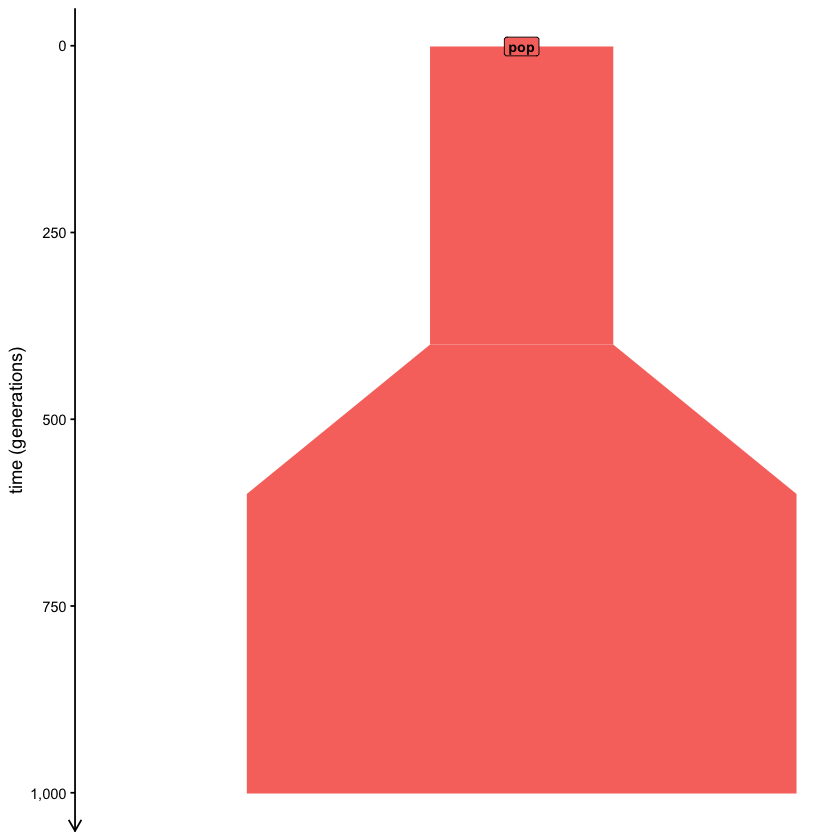

In [63]:
model <- compile_model(populations = pop, generation_time = 1, direction = "forward", simulation_length = 1000)
plot_model(model)

**When you look at `?gene_flow` help page, you see that the function has a `rate` argument too. What does it do? Is there any way to get the same result (i.e., to encode the same gene-flow event) as you did just above, but using `rate` instead of `proportion`? When would you expect to use one or the other?**

### Exercise: Serialized models on disk

A very important part of _slendr_'s approach to modeling is to make simple things be trivially easy. This is largely why expressing even relatively complex models with _slendr_ requires so little code compared to the amount of programming needed with traditional powerful simulators such as [_msprime_](https://tskit.dev/msprime/) and [SLiM](https://messerlab.org/slim/), something you'll see (and hopefully appreciate!) when we get to programming larger models later.

Still, sometimes it's useful to peek behind the curtain and see what exactly is going on inside _slendr_ and how it operates.

**Type out the `model` object in the R console, paying attention to the description of the path. Use your operating system disk browsing program (Finder on macOS, File Explorer on Windows, or any other means of browsing files on other systems, such as the terminal shell) to see what files are hiding in that path.**

In [17]:
list.files(model$path, full.names = TRUE)

[1] "/private/var/folders/7f/n68ck8q969z_d628zqqnl4ch0000gn/T/RtmpZ1SfSL/file1bf677e4648e_slendr_model/checksums.tsv"      
 [2] "/private/var/folders/7f/n68ck8q969z_d628zqqnl4ch0000gn/T/RtmpZ1SfSL/file1bf677e4648e_slendr_model/description.txt"    
 [3] "/private/var/folders/7f/n68ck8q969z_d628zqqnl4ch0000gn/T/RtmpZ1SfSL/file1bf677e4648e_slendr_model/direction.txt"      
 [4] "/private/var/folders/7f/n68ck8q969z_d628zqqnl4ch0000gn/T/RtmpZ1SfSL/file1bf677e4648e_slendr_model/generation_time.txt"
 [5] "/private/var/folders/7f/n68ck8q969z_d628zqqnl4ch0000gn/T/RtmpZ1SfSL/file1bf677e4648e_slendr_model/length.txt"         
 [6] "/private/var/folders/7f/n68ck8q969z_d628zqqnl4ch0000gn/T/RtmpZ1SfSL/file1bf677e4648e_slendr_model/orig_length.txt"    
 [7] "/private/var/folders/7f/n68ck8q969z_d628zqqnl4ch0000gn/T/RtmpZ1SfSL/file1bf677e4648e_slendr_model/populations.tsv"    
 [8] "/private/var/folders/7f/n68ck8q969z_d628zqqnl4ch0000gn/T/RtmpZ1SfSL/file1bf677e4648e_slendr_model/ranges.rds"         
 [9] "/private/var/folders/7f/n68ck8q969z_d628zqqnl4ch0000gn/T/RtmpZ1SfSL/file1bf677e4648e_slendr_model/script.py"          
[10] "/private/var/folders/7f/n68ck8q969z_d628zqqnl4ch0000gn/T/RtmpZ1SfSL/file1bf677e4648e_slendr_model/script.slim"        
[11] "/private/var/folders/7f/n68ck8q969z_d628zqqnl4ch0000gn/T/RtmpZ1SfSL/file1bf677e4648e_slendr_model/time_units.txt"

In [20]:
print_file <- function(model, file) cat(readLines(file.path(model$path, file)))

In [21]:
print_file(model, "populations.tsv")

pop	parent	N	tsplit_gen	tsplit_orig	tremove_gen	tremove_orig	pop_id	parent_id pop	__pop_is_ancestor	5000	1	1	-1	-1	0	-1

In [25]:
print_file(model, "time_units.txt")

generations

In [27]:
print_file(model, "direction.txt")

forward

In [28]:
print_file(model, "description.txt")